# Setup


In [1]:
%pip install ipywidgets
%pip install duckdb
%pip install matplotlib
%pip install seaborn
%pip install scipy
%matplotlib inline

import sys
sys.path.append('../scripts')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import duckdb

In [3]:
features = duckdb.read_csv("features/v1.2/stackoverflow_dba_sqlstorm.csv.gz")
queries = duckdb.read_csv("queries/v1.2/stackoverflow.csv.gz")

In [4]:
data = duckdb.query("""select temperature, count(*), avg(ops) from queries join features using (query) group by temperature order by temperature asc""")
data.show()

┌─────────────┬──────────────┬────────────────────┐
│ temperature │ count_star() │      avg(ops)      │
│   double    │    int64     │       double       │
├─────────────┼──────────────┼────────────────────┤
│         0.0 │            1 │                0.0 │
│         0.1 │            5 │               15.0 │
│         0.2 │            7 │ 29.428571428571427 │
│         0.3 │           11 │  25.90909090909091 │
│         0.4 │           13 │ 14.076923076923077 │
│         0.5 │            9 │ 23.444444444444443 │
│         0.6 │           13 │ 28.153846153846153 │
│         0.7 │           11 │  34.09090909090909 │
│         0.8 │            4 │              10.75 │
│         0.9 │           12 │               23.5 │
│         1.0 │            5 │               31.8 │
│         1.1 │           11 │  30.09090909090909 │
│         1.2 │            7 │ 27.714285714285715 │
│         1.3 │            3 │ 32.333333333333336 │
│         1.4 │            3 │               35.0 │
├───────────

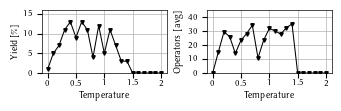

In [10]:
from plot.linestyle import Linestyle
from plot.marker import Marker
from plot.color import Color
from plot.location import Location
from plot.formatter import Decorator, Grid, NumberFormatter, Scale
from plot.lineplot import LinePlot
from plot.frame import Format, GridFrame, Frame, cm2inch, latexify
from matplotlib.patches import Rectangle

d = data.fetchall()
temperatures = [row[0] for row in d] + [1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
counts = [row[1] for row in d] + [0, 0, 0, 0, 0, 0]
avg_ops = [row[2] for row in d] + [0, 0, 0, 0, 0, 0]
x = [0, 0.5, 1, 1.5, 2]

latexify(hyperref=False, increase_font=-1)
frame = GridFrame(width=3.3, height=1, n_rows=1, n_columns=2)
plot = LinePlot(frame[0, 0])
plot.format_axes(xformatter=NumberFormatter(scale=Scale.LINEAR, min=-0.1, max=2.1, grid=Grid.MAJOR, ticks=x, label="Temperature"),
                 yformatter=NumberFormatter(scale=Scale.LINEAR, min=0, max=16, ticks=[0, 5, 10, 15], label="Yield~[\\%]"))
plot.plot(x=temperatures, y=counts, color=Color.BLACK, marker=Marker.TRIANGLE_DOWN)

plot = LinePlot(frame[0, 1])
plot.format_axes(xformatter=NumberFormatter(scale=Scale.LINEAR, min=-0.1, max=2.1, grid=Grid.MAJOR, ticks=x, label="Temperature"),
                 yformatter=NumberFormatter(scale=Scale.LINEAR, min=0, max=45, ticks=[0, 10, 20, 30, 40, 50], label="Operators~[avg]"))
plot.plot(x=temperatures, y=avg_ops, color=Color.BLACK, marker=Marker.TRIANGLE_DOWN)

frame.save(os.path.join("pdf/temperature"), format=Format.PDF)